# IMDb sentiment analysis: walkthrough

This notebook walks through the project from the data to the results:

1. The data (exploration)
2. How the text is cleaned
3. Our reproduction of the paper's Table 2
4. Our improvements over the paper
5. Live predictions

Run every cell from the top (Kernel > Restart & Run All). The results sections read the CSV files in `results/`, so the experiment scripts must have been run first (see the README).

In [11]:
import os, sys
ROOT = os.getcwd() if os.path.isdir("src") else os.path.abspath("..")
sys.path.insert(0, ROOT)
os.chdir(ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import PAPER_BEST_ACCURACY
from src.data import load_raw
from src.evaluate import compare_with_paper, load_all_results
pd.options.display.float_format = "{:.4f}".format

## 1. The data

The Large Movie Review Dataset: 25,000 training and 25,000 test reviews, each half positive and half negative. Reviews rated 4 or less are negative and 7 or more are positive; ratings of 5 and 6 are left out.

In [12]:
train, test = load_raw("train"), load_raw("test")
summary = pd.DataFrame({"reviews": [len(train), len(test)],
                        "positive share": [train.label.mean(), test.label.mean()],
                        "movies": [train.movie.nunique(), test.movie.nunique()]},
                       index=["train", "test"])
display(summary)
print("movies that appear in both train and test:", len(set(train.movie) & set(test.movie)))

,reviews,positive share,movies
train,25000,0.5000,3456
test,25000,0.5000,3581


movies that appear in both train and test: 1


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
ratings = train.rating.value_counts().sort_index()
axes[0].bar(ratings.index, ratings.values, color=["#c0504d" if r <= 4 else "#4f81bd" for r in ratings.index])
axes[0].set_title("Ratings in the training set (red = negative, blue = positive)")
axes[0].set_xlabel("rating"); axes[0].set_ylabel("reviews")

words = train.text.str.split().str.len()
for label, name, colour in ((0, "negative", "#c0504d"), (1, "positive", "#4f81bd")):
    axes[1].hist(words[train.label == label].clip(upper=1000), bins=50, alpha=0.6, label=name, color=colour)
axes[1].set_title("Review length in words (cut at 1,000)")
axes[1].set_xlabel("words"); axes[1].legend()
plt.tight_layout(); plt.show()
print(f"average length {words.mean():.0f} words, median {words.median():.0f}, longest {words.max()}")

average length 234 words, median 174, longest 2470


C:\Users\Vedaraj H R\AppData\Local\Temp\ipykernel_32736\2990710849.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.tight_layout(); plt.show()


### Which words point to each class?

A quick logistic regression on single words (not part of the paper's pipeline) shows what the models pick up.

In [14]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression

vec = CountVectorizer(binary=True, min_df=20, stop_words="english")
X = vec.fit_transform(train.text.str.lower().str.replace("<br />", " ", regex=False))
lr = LogisticRegression(C=0.1, max_iter=1000).fit(X, train.label)
order = np.argsort(lr.coef_[0]); names = vec.get_feature_names_out()
print("most negative:", ", ".join(names[order[:15]]))
print("most positive:", ", ".join(names[order[::-1][:15]]))

most negative: worst, waste, disappointment, awful, poorly, boring, disappointing, dull, worse, avoid, mess, fails, lacks, pointless, poor
most positive: excellent, perfect, refreshing, wonderful, superb, wonderfully, amazing, perfectly, favorite, funniest, great, rare, incredible, enjoyable, surprisingly


## 2. Text cleaning

The paper's cleaning removes punctuation, numbers and stop words and reduces words to their root. We compare it with lighter cleaning that keeps negations such as "not".

In [15]:
from src.preprocess import clean_text
example = train.text.iloc[7]
print("RAW    :", example[:300], "...\n")
for mode in ("paper", "paper_nltk", "minimal"):
    print(f"{mode:11s}:", clean_text(example, mode)[:300], "...\n")

RAW    : This is really a new low in entertainment. Even though there are a lot worse movies out.<br /><br />In the Gangster / Drug scene genre it is hard to have a convincing storyline (this movies does not, i mean Sebastians motives for example couldn't be more far fetched and worn out cliché.) Then you wo ...

paper      : this be really new low entertainment even though there be lot worse movie out gangster drug scene genre it be hard to have convince storyline this movie do not i mean sebastians motif for example couldnt be more far fetch and wear out clich then you would also need set character relationship that be ...

paper_nltk : really new low entertainment even though lot worse movie gangster drug scene genre hard convince storyline movie mean sebastians motif example far fetch wear clich would also need set character relationship believable movie sure tristan draw away family whats deal father ask permission go age intere ...

minimal    : this is really a new low in entert

## 3. Reproduction of the paper's Table 2

Each row compares the paper's accuracy with ours on the same 25,000 test reviews.

In [16]:
table = compare_with_paper()[["model", "vectorization", "paper_accuracy", "accuracy", "accuracy_diff"]]
display(table.rename(columns={"accuracy": "our_accuracy"}))
done = table.dropna(subset=["accuracy"])
print(f"{len(done)} of {len(table)} rows reproduced; mean absolute difference {done.accuracy_diff.abs().mean():.4f}, "
      f"largest {done.accuracy_diff.abs().max():.4f}")

,model,vectorization,paper_accuracy,our_accuracy,accuracy_diff
0,Logistic Regression,binary,0.9000,0.9004,0.0004
1,Logistic Regression,count,0.8970,0.8987,0.0017
2,Logistic Regression,tfidf,0.8770,0.8802,0.0032
3,SVM,binary,0.9010,0.8990,-0.0020
4,SVM,count,0.8980,0.8996,0.0016
5,SVM,tfidf,0.9000,0.9023,0.0023
6,Naive Bayes,binary,0.8810,0.8795,-0.0015
7,Naive Bayes,count,0.8740,0.8731,-0.0009
8,Naive Bayes,tfidf,0.8790,0.8775,-0.0015
9,Random Forest,binary,0.8520,0.8616,0.0096


18 of 18 rows reproduced; mean absolute difference 0.0056, largest 0.0171


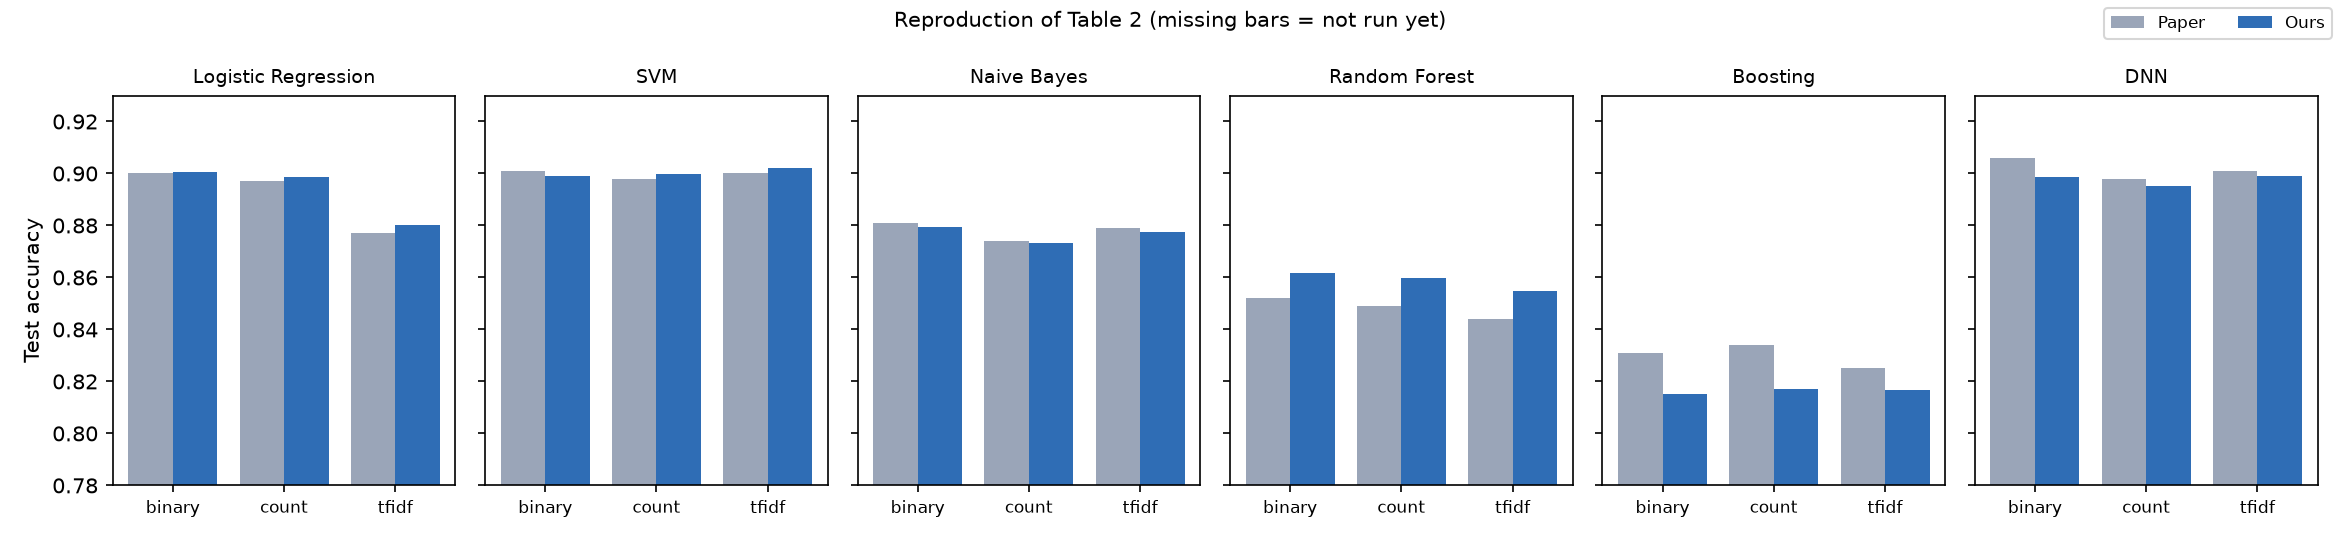

In [17]:
from src.plots import plot_reproduction
from IPython.display import Image
Image(filename=str(plot_reproduction()))

## 4. Improvements over the paper

The paper's best accuracy is 0.906. These are our best models, each chosen on validation data and scored once on the test set.

In [18]:
improved = load_all_results("improve").dropna(subset=["accuracy"]).sort_values("accuracy", ascending=False)
display(improved[["model", "vectorization", "cleaning", "val_accuracy", "accuracy", "f1"]].head(10))
best = improved.iloc[0]
print(f"best: {best.model} ({best.vectorization}) accuracy {best.accuracy:.4f}, "
      f"{best.accuracy - PAPER_BEST_ACCURACY:+.4f} against the paper's best")

,model,vectorization,cleaning,val_accuracy,accuracy,f1
4,"Ensemble (NB-LR + SVM (tf-idf, wide C grid))",mixed,minimal + rich tokens,0.9070,0.9182,0.9187
9,"Ensemble (NB-LR + SVM (tf-idf, wide C grid))",NaN,NaN,NaN,0.9182,NaN
5,NB-LR,NaN,NaN,NaN,0.9160,NaN
0,NB-LR,binary,minimal + rich tokens,0.9059,0.9160,0.9167
20,NB-LR,binary,minimal + rich tokens,0.9059,0.9160,0.9167
19,NB-SVM,binary,minimal + rich tokens,0.9047,0.9157,0.9164
6,NB-SVM,NaN,NaN,NaN,0.9157,NaN
1,NB-SVM,binary,minimal + rich tokens,0.9047,0.9157,0.9164
2,"SVM (tf-idf, wide C grid)",tfidf,minimal + rich tokens,0.8956,0.9089,0.9093
7,"SVM (tf-idf, wide C grid)",NaN,NaN,NaN,0.9089,NaN


best: Ensemble (NB-LR + SVM (tf-idf, wide C grid)) (mixed) accuracy 0.9182, +0.0122 against the paper's best


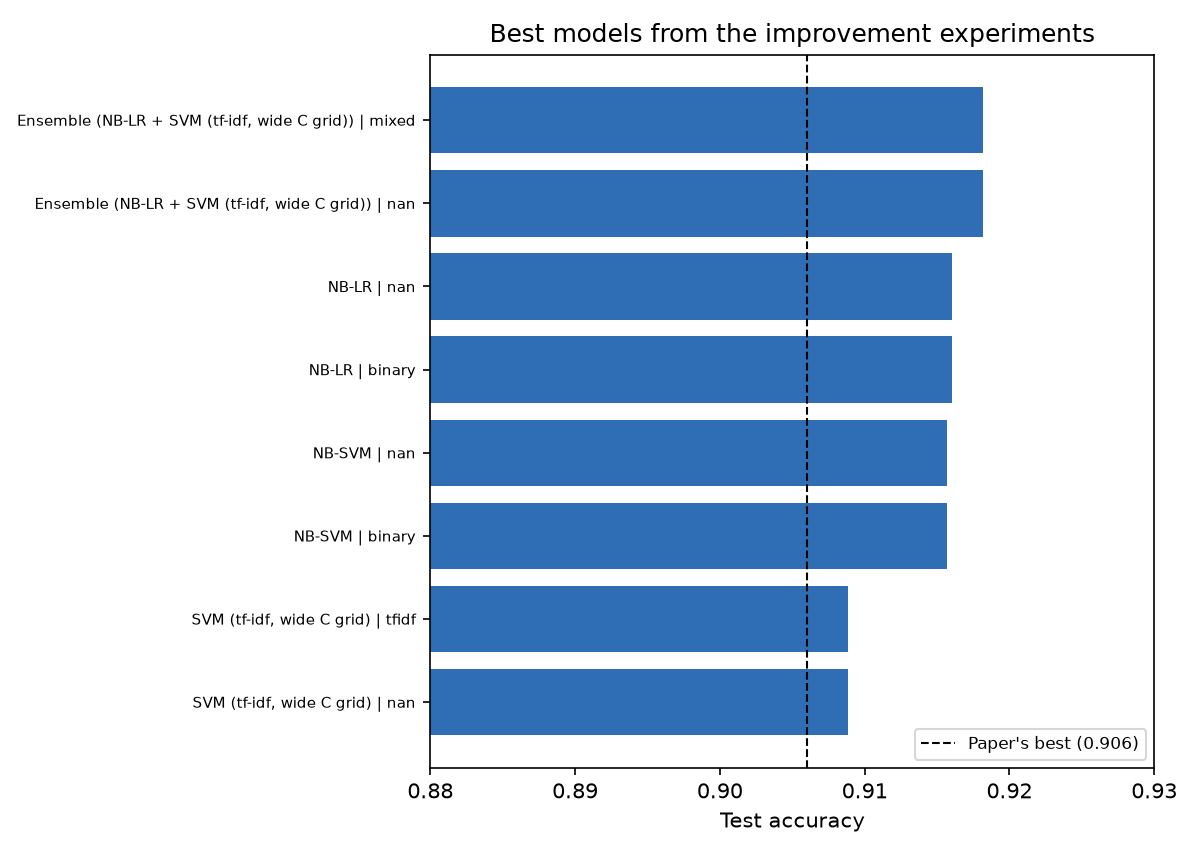

In [19]:
from src.plots import plot_improvements
Image(filename=str(plot_improvements()))

## 5. Live predictions

Type a review into `text` and run the cell. This uses the models saved in `models/` by the experiment scripts.

In [20]:
from src.predict import Predictor
text = "This movie is not good. I did not enjoy it and I would not recommend it to anyone."
try:
    predictor = Predictor()
except Exception as error:
    predictor = None
    print("No saved models found; run the experiment scripts first.", error)
if predictor is not None and predictor.names:
    for name in predictor.names:
        result = predictor.predict(name, text)
        print(f"{name:35s} {'positive' if result['label'] else 'negative'}")
else:
    print("models/ is empty: run `python -m src.experiments.linear_models` and `improve_features` first.")

models/ is empty: run `python -m src.experiments.linear_models` and `improve_features` first.
